<a href="https://colab.research.google.com/github/Yureshka02/Cypress-test/blob/master/Titanic_dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')    #importing drive and mounting the drive

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ETcontent/titanic_dataset (1).csv') #reading the csv file from the drive

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
###--- Data Cleaning ---###

In [7]:
df.drop(['PassengerId','Name','Ticket','Fare'],axis=1,inplace=True) #csv file stays as the same , only the df variable gets changed here

In [9]:
df.head(100)


,Survived,Pclass,Sex,Age,SibSp,Parch,Cabin,Embarked
0,0,3,male,22.0,1,0,NaN,S
1,1,1,female,38.0,1,0,C85,C
2,1,3,female,26.0,0,0,NaN,S
3,1,1,female,35.0,1,0,C123,S
4,0,3,male,35.0,0,0,NaN,S
...,...,...,...,...,...,...,...,...
95,0,3,male,NaN,0,0,NaN,S
96,0,1,male,71.0,0,0,A5,C
97,1,1,male,23.0,0,1,D10 D12,C
98,1,2,female,34.0,0,1,NaN,S


In [16]:
df.fillna(df.Age.mean().round)

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,S
887,1,1,female,19.0,0,0,S
888,0,3,female,<built-in method round of numpy.float64 object...,1,2,S
889,1,1,male,26.0,0,0,C


In [13]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Cabin,687
Embarked,2


In [14]:
df.drop(['Cabin'],axis=1,inplace=True)

In [17]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [19]:
df['Age'].fillna(df['Age'].mean(),inplace=True) # filling the null values of the Age using the mean of the Age

<ipython-input-19-26113ea9078d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [20]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Embarked,2


In [21]:
df['Embarked'].fillna(df['Embarked'].mode(),inplace=True)

<ipython-input-21-c652ea9fa2d2>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode(),inplace=True)


In [23]:
df['Embarked'].fillna(df['Embarked'].mode()[0],inplace=True)# filling the null values in the Embarked with the mode of the particular column

df.isnull().sum()


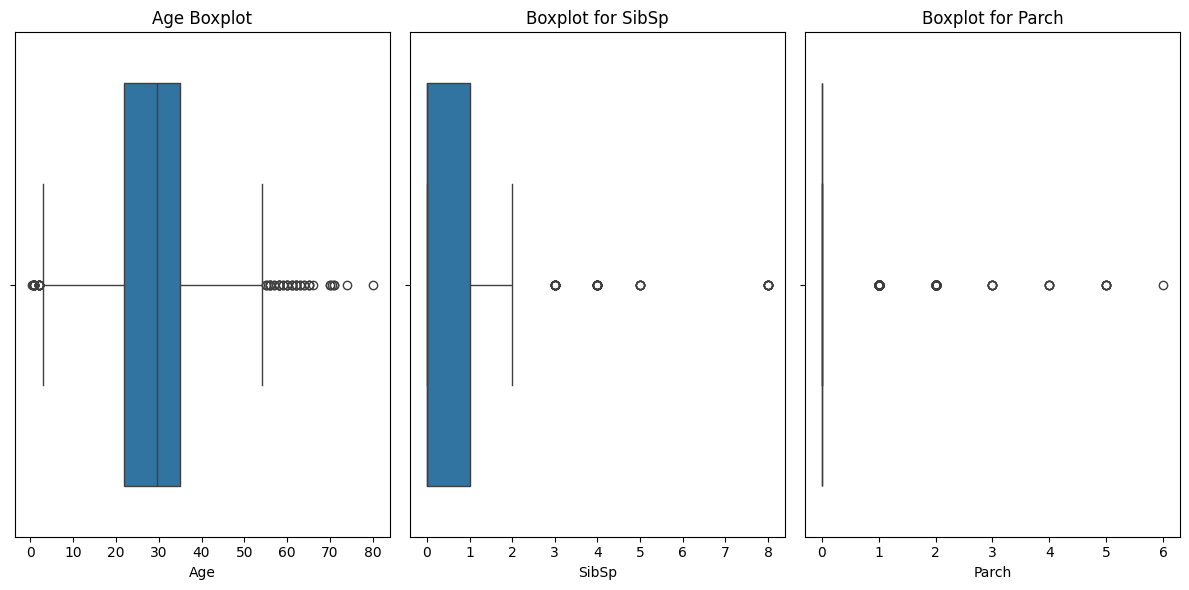

In [31]:
import matplotlib.pyplot as plt #importing the matplotlib.pyplot
import seaborn as sns #importing the seaborn

#code for boxplot graph
plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
sns.boxplot(x=df['Age'])
plt.title('Age Boxplot')

plt.subplot(1,3,2)
sns.boxplot(x=df['SibSp'])
plt.title('Boxplot for SibSp')

plt.subplot(1,3,3)
sns.boxplot(x=df['Parch'])
plt.title('Boxplot for Parch')

plt.tight_layout()
plt.show()



In [ ]:
#calculate the upper quartile limit for the 'Fare'
fare_upper_limit = df['Fare'].quantile(0.75)

#impute 'Fare' values higher than 400 with the upper quartile limit
df['Fare']= np.where(df['Fare'] > 400, fare_upper_limit, df['Fare'])

######################################################################################

In [33]:
###--- Data Transformation ---###
from sklearn.preprocessing import LabelEncoder

df['Sex'] = LabelEncoder().fit_transform(df['Sex'])
df['Embarked'] = LabelEncoder().fit_transform(df['Embarked'])
df.head()

######################################################################################

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,1,22.0,1,0,2
1,1,1,0,38.0,1,0,0
2,1,3,0,26.0,0,0,2
3,1,1,0,35.0,1,0,2
4,0,3,1,35.0,0,0,2


In [34]:
###---Model Training ---###

#Splitting data set into training and testing sets
from sklearn.model_selection import train_test_split

x = df.drop(['Survived'],axis=1)
y = df['Survived']
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)


In [38]:

#Logistic Regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression()
logreg.fit(x_train,y_train)
y_pred_lr = logreg.predict(x_test)

In [48]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, precision_score, f1_score

# Evaluation Metrics
def evaluate_model(y_true, y_pred, model_name):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"{model_name} Accuracy: {accuracy:.2f}")
    print(f"{model_name} Precision: {precision:.2f}")
    print(f"{model_name} Recall: {recall:.2f}")
    print(f"{model_name} F1 Score: {f1:.2f}")
    print(f"{model_name} Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}")

evaluate_model(y_test, y_pred_lr, "Logistic Regression")


Logistic Regression Accuracy: 0.78
Logistic Regression Precision: 0.68
Logistic Regression Recall: 0.71
Logistic Regression F1 Score: 0.69
Logistic Regression Confusion Matrix:
[[96 21]
 [18 44]]
